In [104]:
import numpy as np
import scipy as sp 
import diffrax as dx
import matplotlib.pyplot as plt
import jax.random as jr
import jax.numpy as jnp
import jax
import jax.scipy as jsp

[[1.00000000e+00]
 [1.05024887e+00]
 [1.10302266e+00]
 [1.15844827e+00]
 [1.21665895e+00]
 [1.27779466e+00]
 [1.34200237e+00]
 [1.40943643e+00]
 [1.48025897e+00]
 [1.55464027e+00]
 [1.63275914e+00]
 [1.71480340e+00]
 [1.80097028e+00]
 [1.89146695e+00]
 [1.98651098e+00]
 [2.08633090e+00]
 [2.19116665e+00]
 [2.30127021e+00]
 [2.41690634e+00]
 [2.53835308e+00]
 [2.66590239e+00]
 [2.79986090e+00]
 [2.94055066e+00]
 [3.08830993e+00]
 [3.24349392e+00]
 [3.40647573e+00]
 [3.57764719e+00]
 [3.75741982e+00]
 [3.94622581e+00]
 [4.14451909e+00]
 [4.35277637e+00]
 [4.57149834e+00]
 [4.80121084e+00]
 [5.04246613e+00]
 [5.29584422e+00]
 [5.56195425e+00]
 [5.84143600e+00]
 [6.13496138e+00]
 [6.44323607e+00]
 [6.76700121e+00]
 [7.10703517e+00]
 [7.46415545e+00]
 [7.83922061e+00]
 [8.23313236e+00]
 [8.64683772e+00]
 [9.08133130e+00]
 [9.53765767e+00]
 [1.00169139e+01]
 [1.05202522e+01]
 [1.10488827e+01]
 [1.16040763e+01]
 [1.21871676e+01]
 [1.27995587e+01]
 [1.34427217e+01]
 [1.41182029e+01]
 [1.482762

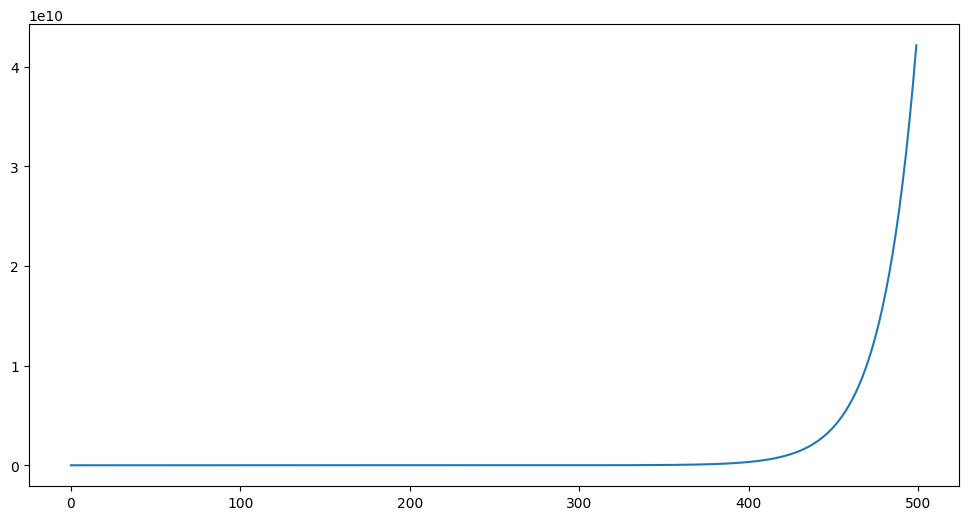

In [9]:
def od_1(k,t, y):
    # growth/decay/interest
    dydt = k*y
    
    return dydt
     
y0 = 1.0
t = np.linspace(1, 10, 500)
k = np.e 
sol = sp.integrate.odeint(od_1, y0, t, args=(k,))

print(sol)

fig,ax = plt.subplots(figsize=(12,6))
ax.plot(sol)


In [15]:
def od_2(t0, t1):
    # itô SDE
    
    dyt = lambda t, y, args: -y
    diff = lambda t, y, args: 0.1 * t 
    
    brow_mot = dx.VirtualBrownianTree(t0, t1, tol=1e-6, shape=(), key=jr.PRNGKey(42))
    terms = dx.MultiTerm(dx.ODETerm(dyt), dx.ControlTerm(diff, brow_mot))
    solver = dx.Euler()
    
    saveat = dx.SaveAt(dense=True)
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.05, y0=1.0, saveat=saveat)
    
    return sol 

sol = od_2(0, 10)
sol.evaluate(1.1, 9.8)

Array(-1.089436, dtype=float32)

In [27]:
def od_3(k,m,i_t,t0,t1):
    w = k/m
    
    def dyn(t,y,args):
        theta, omega = y
        d_t = omega
        d_o = -w * theta
        
        return jnp.stack([d_t, d_o])
    
    term = dx.ODETerm(dyn)
    solver = dx.Tsit5()
    
    y0 = jnp.array([i_t, 0.0])
    
    saveat = dx.SaveAt(ts=np.linspace(t0,t1,1000), dense=True)
    
    sol = dx.diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=0.1,
        y0=y0,
        saveat=saveat
    )

    return sol
    

sol = od_3(4.0,1.0,0.2,0.0,12.0)
sol.evaluate(0.0, 12.0)

Array([-0.115164  ,  0.36223137], dtype=float32)

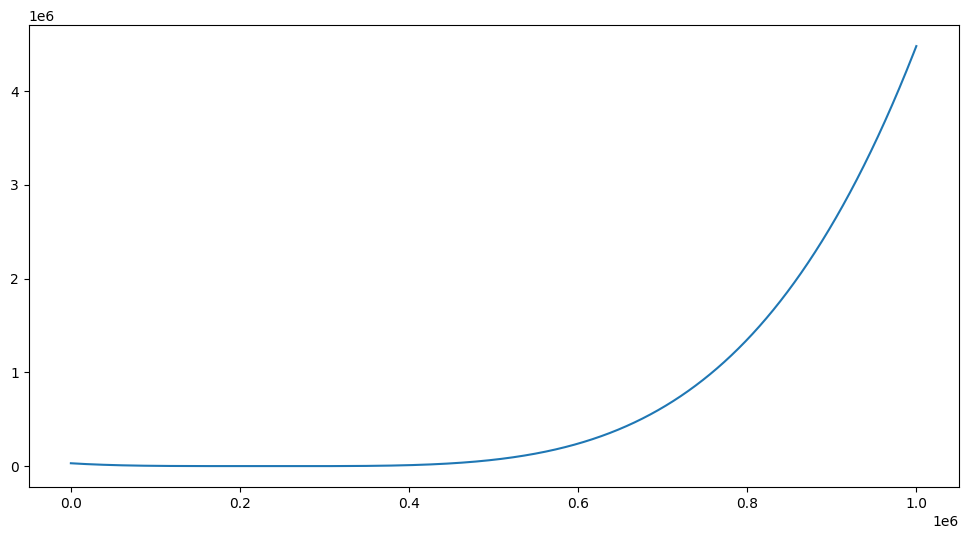

In [51]:
x = np.linspace(-10.0, 40.0, num=10**6)


arr = (x**4 - x**3  - (x**3)*10 + (x**2 + 10) - (x * 20) - 10) * np.random.randint(0,1,1) - 11

coeffs = [2, -10, 1, -20, 10]
arr = np.polyval(coeffs, x)

arr[5000]

fig,ax = plt.subplots(figsize=(12,6))
ax.plot(arr)

$ d\theta = \omega dt$  



$d\omega = - \frac{g}{L} sin(\theta)dt$

Para uma SDE (ito), adicionando um termo de difusão $dW_t$ (Movimento Browiniano)

$dw =  - \frac{g}{L} sin(\theta)dt + \alpha dW_t$

In [ ]:
import lineax as lx
def sol_sde_pend(k, m, t_0, sigm, t0, t1, key):
    
    w_sq = k / m
    
    def drift(t,y,args):
        theta, omega = y
        return jnp.stack([omega, -w_sq * jnp.sin(theta)])

    def diff(t, y, args):
        diagonal = jnp.stack([0.0, sigm])
        return lx.DiagonalLinearOperator(diagonal)
        
    brow_m = dx.VirtualBrownianTree(t0, t1, tol=1e-3, shape=(2,), key=key)
    terms = dx.MultiTerm(dx.ODETerm(drift), dx.ControlTerm(diff, brow_m))
    
    solver = dx.Euler()
    
    y0 = jnp.array([t_0, 0.0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,1000), dense=True)
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0, saveat=saveat)
    
    return sol 

key = jr.PRNGKey(42)
sol = sol_sde_pend(4.0, 1.0, 2.0, 0.5, 0, 20, key)

# Print solution info
print(f"Time span: {sol.t0} to {sol.t1}")
print(f"Number of saved points: {len(sol.ts)}")
print(f"Solution shape: {sol.ys.shape}")
print(f"First state (theta, omega): {sol.ys[:, 0]}")
print(f"Last state (theta, omega): {sol.ys[:, -1]}")

Time span: 0.0 to 20.0
Number of saved points: 1000
Solution shape: (1000, 2)
First state (theta, omega): [ 2.00000000e+00  1.99939179e+00  1.99908781e+00  1.99780738e+00
  1.99645162e+00  1.99350464e+00  1.99054992e+00  1.98749232e+00
  1.98175085e+00  1.97381723e+00  1.96351254e+00  1.95087171e+00
  1.93725431e+00  1.92219234e+00  1.90517938e+00  1.88573349e+00
  1.86541188e+00  1.84280384e+00  1.82084298e+00  1.79770327e+00
  1.77505887e+00  1.75049686e+00  1.72398758e+00  1.69647658e+00
  1.66810000e+00  1.63824856e+00  1.60741043e+00  1.57416105e+00
  1.53786409e+00  1.49799180e+00  1.45448685e+00  1.40917408e+00
  1.36187899e+00  1.31406164e+00  1.26468468e+00  1.21290839e+00
  1.16069770e+00  1.10663176e+00  1.05230844e+00  9.96331930e-01
  9.35461044e-01  8.71699333e-01  8.05329204e-01  7.38192201e-01
  6.70676529e-01  6.00310922e-01  5.30082464e-01  4.59921360e-01
  3.90437722e-01  3.19393963e-01  2.46654451e-01  1.72888309e-01
  9.86387655e-02  2.58004628e-02 -4.75315973e-02 

In [61]:
print(f"sol.ts shape: {sol.ts.shape}")
print(f"sol.ys shape: {sol.ys.shape}")

sol.ts shape: (1000,)
sol.ys shape: (1000, 2)


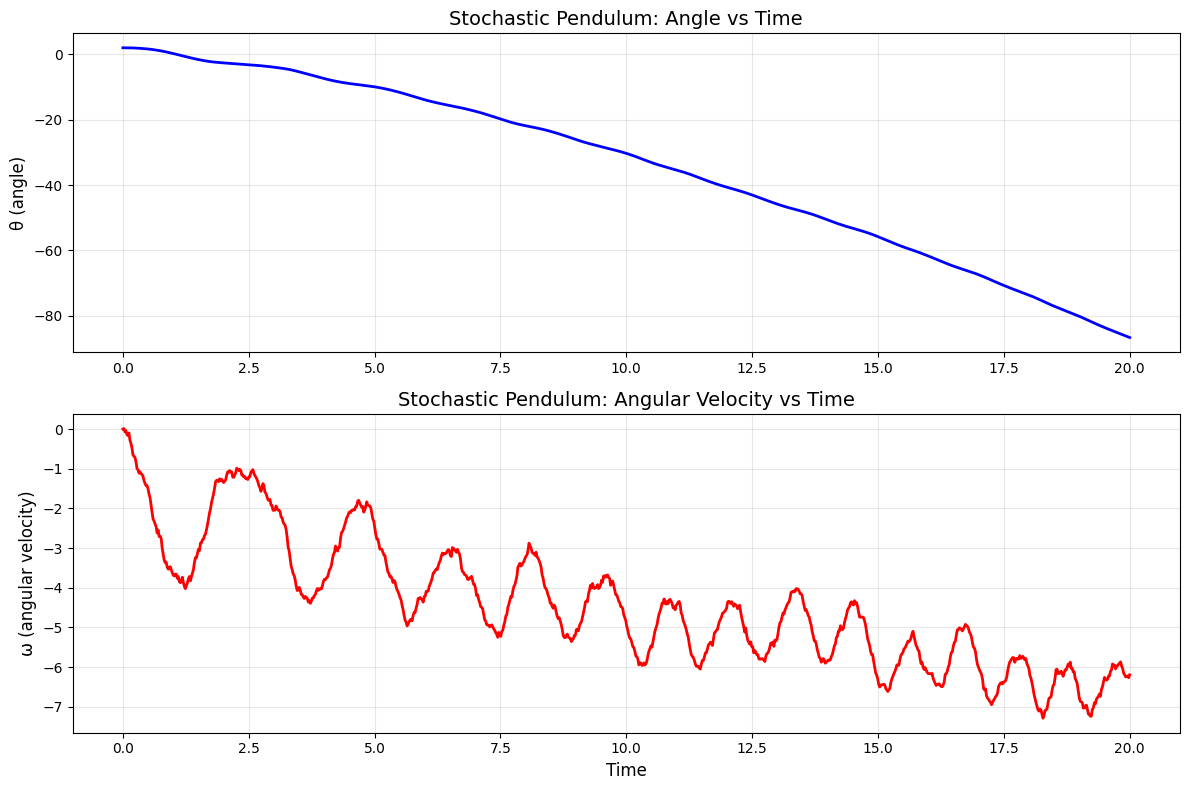

In [62]:
# Plot the solution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot theta (angle)
ax1.plot(sol.ts, sol.ys[:, 0], 'b-', linewidth=2)
ax1.set_ylabel('θ (angle)', fontsize=12)
ax1.set_title('Stochastic Pendulum: Angle vs Time', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot omega (angular velocity)
ax2.plot(sol.ts, sol.ys[:, 1], 'r-', linewidth=2)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('ω (angular velocity)', fontsize=12)
ax2.set_title('Stochastic Pendulum: Angular Velocity vs Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

More examples of ODE's with brownian motion

More investigations for the brownian motion

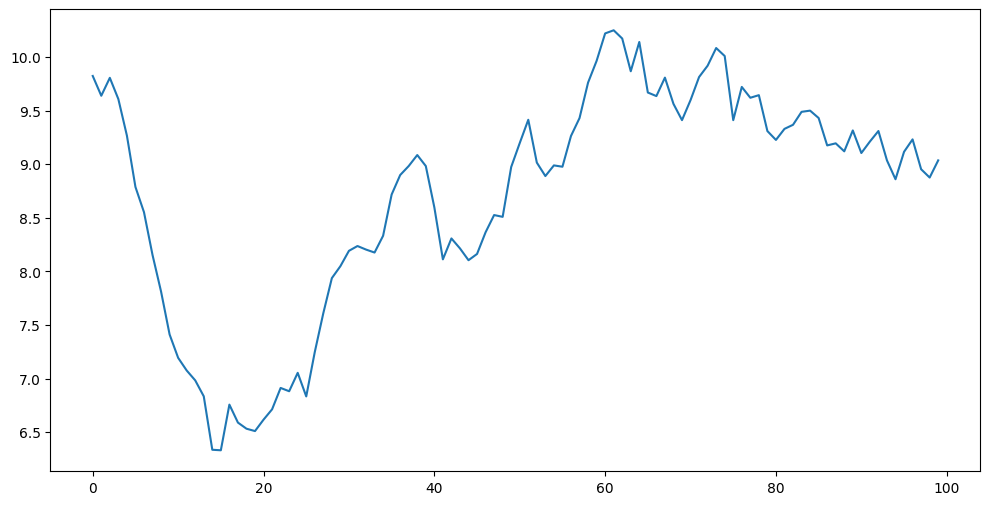

In [65]:
import scipy.stats as st 

delta = 0.25
dt = 0.1

x = 10.0
vec = [i for i in range(100)]
for i in range(100):
    x = x + st.norm.rvs(scale=delta**2**dt)
    #print(x)
    vec[i] = x
    
fig,ax = plt.subplots(figsize=(12,6))
ax.plot(vec)

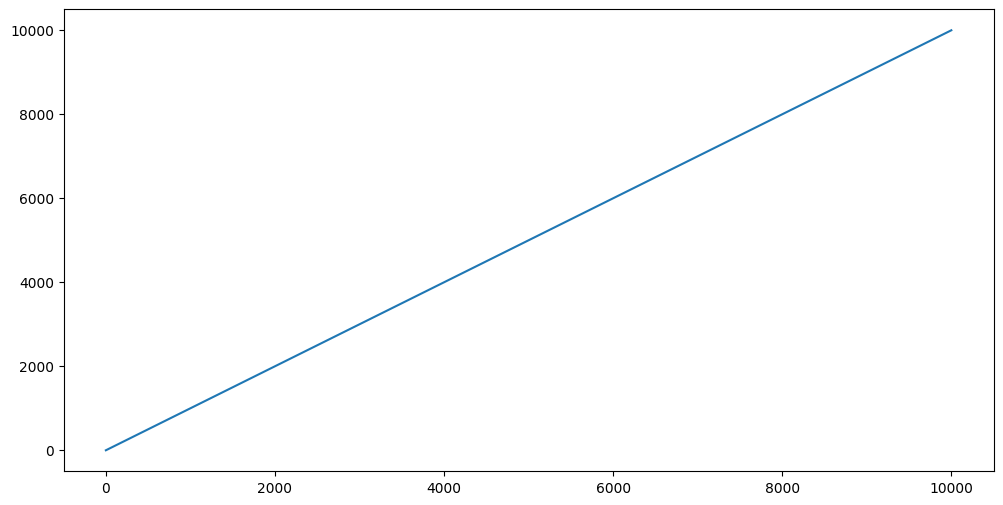

In [72]:
f = lambda x : x * jr.randint(minval=5, maxval=40) / 10

key = jr.PRNGKey(45)
def f(x,sub):
    rnd_val = jr.randint(sub, shape=(), minval=0, maxval=40)
    return x * (rnd_val / 10)

vec = jnp.arange(10_000)
keys = jr.split(key, 10_000)

vec_f = jax.vmap(f)

figas = vec_f(vec, keys)

fig,ax = plt.subplots(figsize=(12,6))
ax.plot(vec)

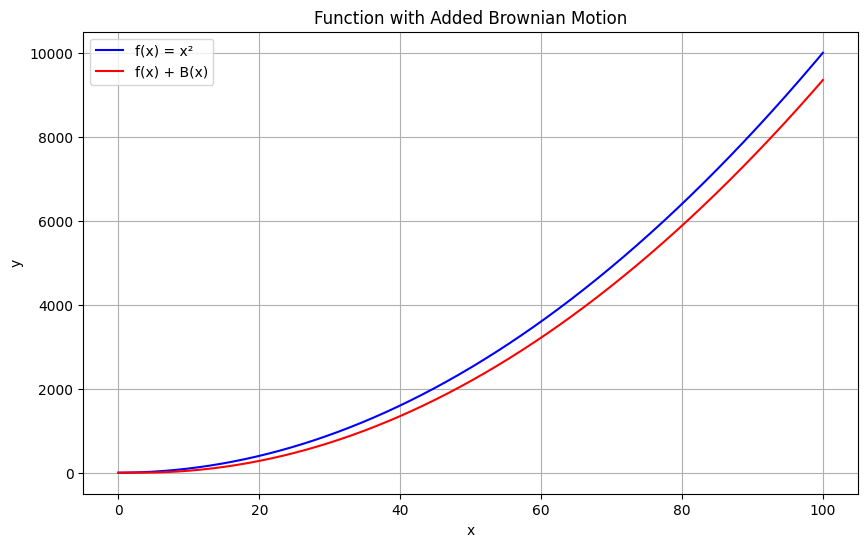

In [81]:
def build_f_with_brow(f, key, T, n):
    if key is None:
        key = jax.random.PRNGKey(0)
        
    dt = T / n
    t = jnp.linspace(0, T, n+1)
    
    dw = jr.normal(key, (n,)) * jnp.sqrt(dt)
    
    W = jnp.cumsum(dw)
    W = jnp.insert(W, 0, 0.0)
    
    def brow_interpolation(x):
        idx = jnp.searchsorted(t, x, side='right') - 1
        idx = jnp.clip(idx, 0, len(t) - 2)
        
        t0, t1 = t[idx], t[idx+1]
        w0, w1 = W[idx], W[idx+1]
        
        return w0 + (x - t0) * (w1 - w0) / (t1 - t0)
    
    return lambda x: f(x) + brow_interpolation(x)

f = lambda x : x**2 + 2

f_b = build_f_with_brow(f, key, 2.0, 1000)

x_axis = jnp.linspace(0, 100, 9000)
y_axis = f_b(x_axis)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, f(x_axis), 'b-', label='f(x) = x²')
plt.plot(x_axis, y_axis, 'r-', label='f(x) + B(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function with Added Brownian Motion')
plt.legend()
plt.grid(True)
plt.show()

In [96]:
#ornstein-Uhlenbeck process (Mean Reversion)
# is widely used in physics and finance to model system that evolve towards a long-term avarege

def sol_sde_ou(theta, mu, sigma, t0, t1, y0_val, key):
    # theta: speed of reversion, mu: long-term mean, sigma: volatility
    
    def drift(t,y,args):
        return theta * (mu-y)
    def diff(t,y,args):
        #diag = jnp.stack([0.0, sigma])
        #return lx.DiagonalLinearOperator(diagonal=diag)
        #return sigma
        return jnp.array([sigma])
    
    brow_m = dx.VirtualBrownianTree(t0, t1, tol=1e-4, shape=(), key=key)
    terms = dx.MultiTerm(dx.ODETerm(drift), dx.ControlTerm(diff, brow_m))
    
    solver = dx.Euler()
    y0 = jnp.array([y0_val])
    
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,1000))
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0, saveat=saveat)
    
    return sol

### Geometric Brownian Motion GBM 
# Standard model for stock prices, where the drift and diffusion are proportional to the current value

def sol_sde_gbm(mu, sigma, t0,t1, y0_val, key):
    #mu = drift (percentage drift) , sigma: percentage volatitlity
    
    def drift(t, y, args):
        return mu *y 
    def diff(t, y, args):
        return sigma * y
    
    brow_m = dx.VirtualBrownianTree(t0, t1, tol=1e-3, shape=(), key=key)
    terms = dx.MultiTerm(dx.ODETerm(drift), dx.ControlTerm(diff, brow_m))

    solver = dx.Euler()
    y0 = jnp.array([y0_val])
    
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,1000))
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0, saveat=saveat)
    
    return sol 

def sol_sde_lorenz(sigma, rho, beta, noise_scale, t0, t1, key):
    # Standard Lorenz parameters: sigma=10, rho=28, beta=8/3
    
    def drift(t, y, args):
        x, v, z = y
        dx = sigma * (v - x)
        dv = x * (rho - z) - v
        dz = x * v - beta * z
        return jnp.stack([dx, dv, dz])

    def diff(t, y, args):
        # Diagonal noise applied to all three dimensions
        diagonal = jnp.array([noise_scale, noise_scale, noise_scale])
        return lx.DiagonalLinearOperator(diagonal)
        
    brow_m = dx.VirtualBrownianTree(t0, t1, tol=1e-3, shape=(3,), key=key)
    terms = dx.MultiTerm(dx.ODETerm(drift), dx.ControlTerm(diff, brow_m))
    
    solver = dx.Euler() # For chaotic systems, dx.Heun() is often more stable
    y0 = jnp.array([1.0, 1.0, 1.0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0, t1, 1000))
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.005, y0=y0, saveat=saveat)
    return sol

### Black-Scholes

$$ \frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial ^2V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0 $$

In [119]:
'''
S -> current underlying price 
K -> Strike price 
T -> time to maturity (years)
r -> risk-free interest rate
sig -> volarility of the underlying stock
q -> dividend yield
t -> current time
'''

def bl_call(S, K, T, t, r, q, sig):
    tau = T - t
    
    tau = jnp.maximum(tau, 1e-8)
    
    sqrt_tau = jnp.sqrt(tau)
    
    d1 = (jnp.log(S / K) + (r - q + 0.5 * sig**2)* tau) / (sig * sqrt_tau)
    d2 = (d1 - (sig*sqrt_tau))
    
    N_d1 = jsp.stats.norm.cdf(d1)
    N_d2 = jsp.stats.norm.cdf(d2)
    
    #N_d1 = sp.stats.norm.cdf(d1)
    #N_d2 = sp.stats.norm.cdf(d2)
    
    price = S * jnp.exp(-q * tau) * N_d1 - K * jnp.exp(-r * tau) * N_d2 
    
    return price

In [121]:
S = 98.0
K = 100.0
T = 1.0
t = 0.0
r = 0.05
sig = 0.2
q = 0.2

price = bl_call(S, K, T, t, r, q, sig) 
print(f"Option Price {price}")

Option Price 1.912221908569336


In [97]:
key = jr.PRNGKey(42)
sol = sol_sde_ou(1.5, 0.0, 0.3, 0.0, 20.0, 2.0, key)

print(f"Time span: {sol.t0} to {sol.t1}")
print(f"Number of saved points: {len(sol.ts)}")
print(f"Solution shape: {sol.ys.shape}")
print(f"First state (theta, omega): {sol.ys[:, 0]}")
print(f"Last state (theta, omega): {sol.ys[:, -1]}")

Time span: 0.0 to 20.0
Number of saved points: 1000
Solution shape: (1000, 1)
First state (theta, omega): [ 2.00000000e+00  1.99789929e+00  1.98685706e+00  1.98789966e+00
  1.97278214e+00  1.96440399e+00  1.96516848e+00  1.91844523e+00
  1.86774516e+00  1.83073950e+00  1.76763821e+00  1.69576216e+00
  1.66031384e+00  1.53534865e+00  1.44157910e+00  1.45972621e+00
  1.38243079e+00  1.31566024e+00  1.33154464e+00  1.30702245e+00
  1.32546556e+00  1.22225165e+00  1.23348653e+00  1.15481174e+00
  1.16050565e+00  1.08183289e+00  1.06067860e+00  1.07711065e+00
  1.10823286e+00  1.02698362e+00  1.01780427e+00  9.96152043e-01
  1.00743699e+00  1.00725722e+00  9.98724818e-01  9.44403946e-01
  9.62714791e-01  9.38575268e-01  8.82102787e-01  8.75826538e-01
  8.79390717e-01  8.68887424e-01  8.06080759e-01  7.86580384e-01
  7.42493749e-01  6.58249795e-01  5.73186159e-01  5.08216143e-01
  5.18481493e-01  5.37446916e-01  4.72303092e-01  4.59645152e-01
  4.42106038e-01  4.39948827e-01  4.67741162e-01 

In [99]:
sol_2 = sol_sde_gbm(0.1, 0.25, 0.0, 20.0, 100.0, key)

print(f"Time span: {sol_2.t0} to {sol_2.t1}")
print(f"Number of saved points: {len(sol_2.ts)}")
print(f"Solution shape: {sol_2.ys.shape}")
print(f"First state (theta, omega): {sol_2.ys[:, 0]}")
print(f"Last state (theta, omega): {sol_2.ys[:, -1]}")

Time span: 0.0 to 20.0
Number of saved points: 1000
Solution shape: (1000, 1)
First state (theta, omega): [100.       105.34311  108.30722  115.7135   120.387276 124.552666
 131.90804  132.92827  134.75114  137.07121  136.20767  134.03642
 135.21756  127.45579  122.611    129.21275  125.43312  123.62947
 129.73479  131.59741  137.79396  131.03818  136.85054  131.64552
 136.65454  131.23228  133.47455  138.72362  146.58463  142.20567
 143.6938   145.05672  151.6194   154.62419  157.89317  154.93152
 161.47961  160.36595  158.95833  161.16129  166.57925  169.39438
 163.55836  164.4295   160.39754  154.3347   146.11333  140.01443
 143.35358  147.72218  141.74706  142.14449  141.93723  142.84064
 149.86838  154.91003  157.52446  160.0468   150.35394  157.49681
 161.11847  156.07613  166.96463  164.92128  166.79492  164.83884
 163.12921  161.01784  160.45995  156.22668  162.16745  151.27197
 146.38765  142.78348  133.67767  139.98874  139.1932   145.18977
 148.87898  154.12323  151.9759   1

In [100]:
sol_3 = sol_sde_lorenz(10.0, 28.0, 2.667, 0.5, 0.0, 20.0, key)

print(f"Time span: {sol_3.t0} to {sol_3.t1}")
print(f"Number of saved points: {len(sol_3.ts)}")
print(f"Solution shape: {sol_3.ys.shape}")
print(f"First state (theta, omega): {sol_3.ys[:, 0]}")
print(f"Last state (theta, omega): {sol_3.ys[:, -1]}")

Time span: 0.0 to 20.0
Number of saved points: 1000
Solution shape: (1000, 3)
First state (theta, omega): [  1.           1.130188     1.3191336    1.6632342    2.0564353
   2.5450706    3.237969     3.9924765    4.957451     6.154778
   7.5755696    9.285603    11.340898    13.523748    15.8483515
  18.179115    19.763584    20.31168     19.58221     17.320492
  14.053409    10.100737     6.399154     2.940807     0.18633543
  -2.186213    -3.930855    -5.229234    -6.189192    -7.05883
  -7.6304164   -8.005136    -8.169864    -8.271907    -8.2536
  -8.241803    -8.071186    -7.9603863   -7.818184    -7.633658
  -7.4853206   -7.3779483   -7.4175754   -7.3767695   -7.412834
  -7.521694    -7.6633873   -7.7774553   -7.782982    -7.841763
  -8.068811    -8.232145    -8.416632    -8.576823    -8.681708
  -8.829934    -8.997756    -9.186257    -9.447923    -9.448985
  -9.465338    -9.568118    -9.4448      -9.413425    -9.271157
  -9.143167    -8.949192    -8.737362    -8.506622    -8.3166

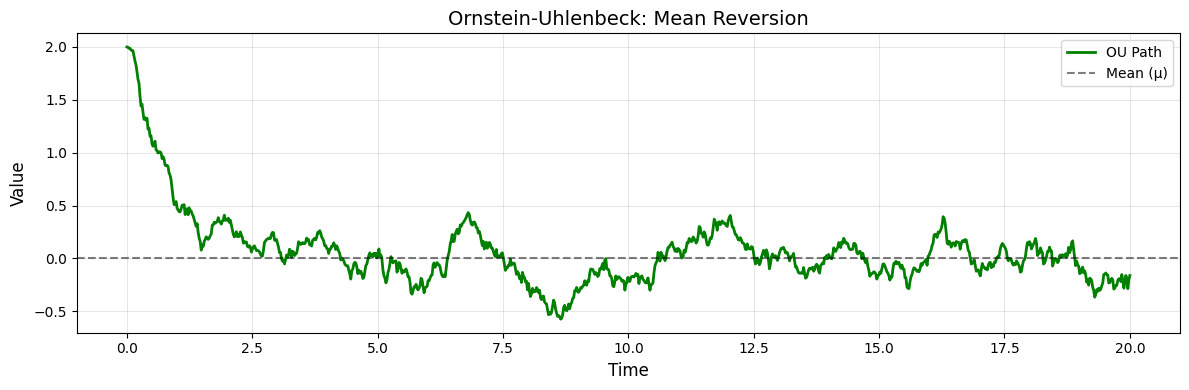

In [101]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(sol.ts, sol.ys[:, 0], 'g-', linewidth=2, label='OU Path')
ax.axhline(y=0.0, color='black', linestyle='--', alpha=0.5, label='Mean (μ)') # mu=0.0
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Ornstein-Uhlenbeck: Mean Reversion', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

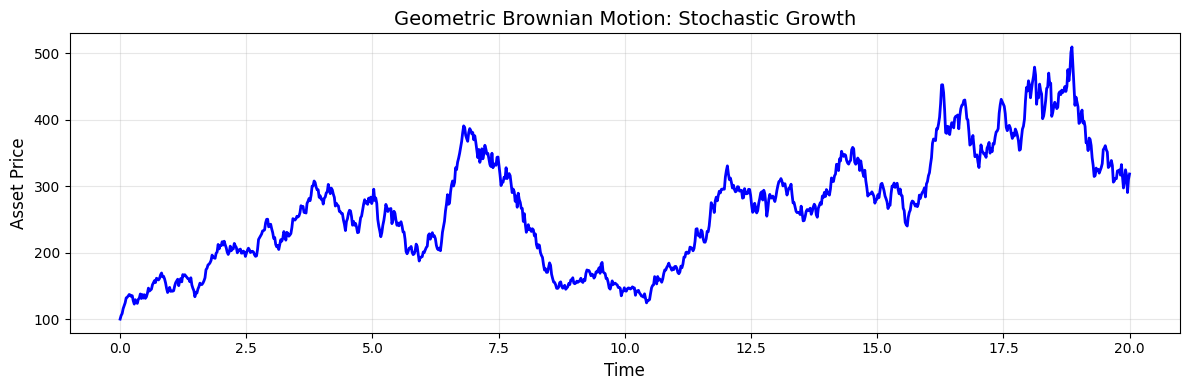

In [102]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(sol_2.ts, sol_2.ys[:, 0], 'b-', linewidth=2)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Asset Price', fontsize=12)
ax.set_title('Geometric Brownian Motion: Stochastic Growth', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

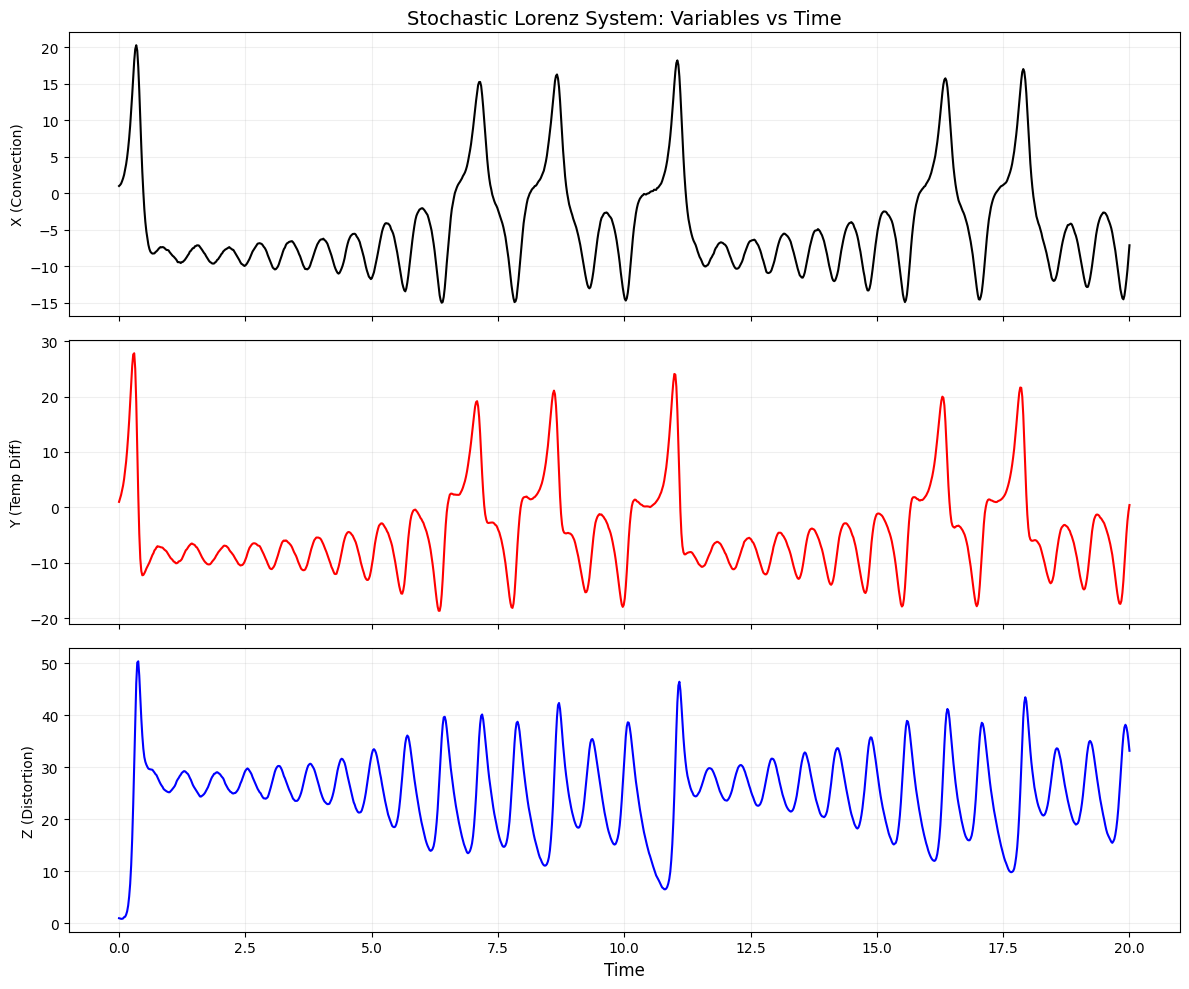

In [103]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax1.plot(sol_3.ts, sol_3.ys[:, 0], 'k-', linewidth=1.5)
ax1.set_ylabel('X (Convection)', fontsize=10)
ax1.set_title('Stochastic Lorenz System: Variables vs Time', fontsize=14)

ax2.plot(sol_3.ts, sol_3.ys[:, 1], 'r-', linewidth=1.5)
ax2.set_ylabel('Y (Temp Diff)', fontsize=10)

ax3.plot(sol_3.ts, sol_3.ys[:, 2], 'b-', linewidth=1.5)
ax3.set_ylabel('Z (Distortion)', fontsize=10)
ax3.set_xlabel('Time', fontsize=12)

for ax in [ax1, ax2, ax3]: ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()